# Exploration

Shape du dataset : (157132, 34)

Colonnes disponibles :
['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name', 'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a', 'conversation_b', 'conv_turns', 'selected_category', 'is_unedited_prompt', 'conversation_pair_id', 'session_hash', 'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a', 'conv_useful_b', 'conv_creative_a', 'conv_creative_b', 'conv_clear_formatting_a', 'conv_clear_formatting_b', 'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a', 'conv_superficial_b', 'conv_instructions_not_followed_a', 'conv_instructions_not_followed_b', 'system_prompt_b', 'system_prompt_a', 'conv_complete_a', 'conv_complete_b']

Types des colonnes :
id                                           int64
timestamp                           datetime64[us]
model_a_name                                object
model_b_name                                object
model_pair_name                             object
cho

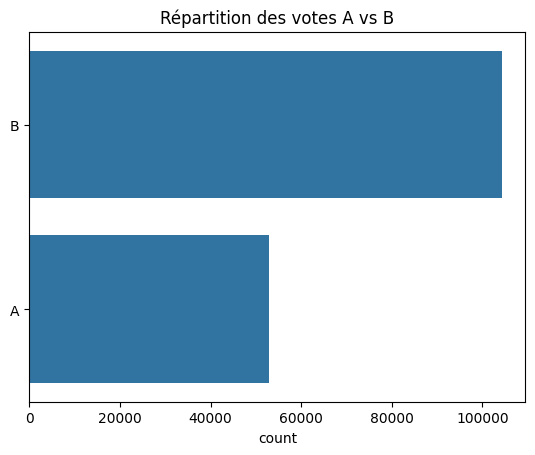

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. CHARGEMENT DONNEES
# ==============================
df = pd.read_parquet("data/votes.parquet")
print("Shape du dataset :", df.shape)
print("\nColonnes disponibles :")
print(df.columns.tolist())

# ==============================
# 2. TYPES ET VALEURS MANQUANTES
# ==============================
print("\nTypes des colonnes :")
print(df.dtypes)

print("\nValeurs manquantes par colonne :")
print(df.isna().sum())

# ==============================
# 3. STATISTIQUES DESCRIPTIVES
# ==============================
print("\nStatistiques numériques :")
print(df.describe())

print("\nStatistiques catégorielles (top 10 valeurs par colonne) :")
for col in ["model_a_name","model_b_name","chosen_model_name","model_pos","selected_category"]:
    if col in df.columns:
        print(f"\nColonne : {col}")
        print(df[col].value_counts().head(10))

# ==============================
# 4. DISTRIBUTION DES LONGUEURS
# ==============================
for col in ["total_conv_a_output_tokens","total_conv_b_output_tokens"]:
    if col in df.columns:
        plt.figure(figsize=(6,3))
        sns.histplot(df[col], bins=50, kde=True)
        plt.title(f"Distribution {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

# ==============================
# 5. VERIFICATION DES CHOIX DE MODELE
# ==============================
if all(c in df.columns for c in ["model_a_name","model_b_name","chosen_model_name"]):
    vote_counts = df.apply(lambda row: 'A' if row["chosen_model_name"]==row["model_a_name"] else 'B', axis=1)
    sns.countplot(vote_counts)
    plt.title("Répartition des votes A vs B")
    plt.show()

# Biais de longueur

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# ==============================
# 1. CHARGEMENT DONNEES
# ==============================
df = pd.read_parquet("data/votes.parquet")
df["total_conv_a_output_tokens"] = df["conversation_a"].apply(lambda x: len(str(x).split()))
df["total_conv_b_output_tokens"] = df["conversation_b"].apply(lambda x: len(str(x).split()))
cols_needed = ["model_a_name","model_b_name","chosen_model_name",
               "total_conv_a_output_tokens","total_conv_b_output_tokens"]
assert all(c in df.columns for c in cols_needed), "Colonnes manquantes !"

# ==============================
# 2. DIFFÉRENCE DE LONGUEUR
# ==============================
df["delta_tokens"] = df["total_conv_a_output_tokens"] - df["total_conv_b_output_tokens"]

df["vote_a"] = (df["chosen_model_name"] == df["model_a_name"]).astype(int)

# ==============================
# 3. CORRÉLATION SIMPLE
# ==============================
corr, pval = pearsonr(df["delta_tokens"], df["vote_a"])
print("Corrélation delta_tokens vs vote A :", corr)
print("p-value :", pval)

if corr > 0:
    print("Les réponses plus longues pour A tendent à être votées plus souvent.")
elif corr < 0:
    print("Les réponses plus longues pour B tendent à être votées plus souvent.")
else:
    print("Pas d’effet apparent de la longueur sur le vote.")

# ==============================
# 4. RÉGRESSION LOGISTIQUE AVEC LONGUEUR COMME COVARIABLE
# ==============================
X = sm.add_constant(df[["delta_tokens"]])  
y = df["vote_a"]

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=False)

print("\n=== Régression logistique ===")
print(result.summary())

# ==============================
# 5. CLASSEMENT BRADLEY-TERRY (ALGORITHME DE ZERMELO)
# ==============================

def bradley_terry_mle(W, tol=1e-8, max_iter=10_000):
    """ Estime les paramètres beta du modèle Bradley-Terry (Algorithme de Zermelo) """
    n = W.shape[0]
    N = W + W.T  
    wins = W.sum(axis=1) 
    
    beta = np.ones(n) / n 

    for iteration in range(max_iter):
        beta_old = beta.copy()
        
        beta_sum = beta[:, None] + beta[None, :]
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(N > 0, N / beta_sum, 0.0)
        denom = ratio.sum(axis=1)

        beta = np.where(denom > 0, wins / denom, 0.0)
        
        total = beta.sum()
        if total > 0:
            beta /= total

        if np.linalg.norm(beta - beta_old, ord=1) < tol:
            print(f"Convergence atteinte à l'itération {iteration + 1}")
            break
    return beta


all_models = sorted(pd.concat([df["model_a_name"], df["model_b_name"]]).unique())
model_to_idx = {model: i for i, model in enumerate(all_models)}
n_models = len(all_models)

W = np.zeros((n_models, n_models))

for _, row in df.iterrows():
    idx_a = model_to_idx[row["model_a_name"]]
    idx_b = model_to_idx[row["model_b_name"]]
    
    if row["chosen_model_name"] == row["model_a_name"]:
        W[idx_a, idx_b] += 1
    else:
        W[idx_b, idx_a] += 1

weights = bradley_terry_mle(W)

model_ranking = pd.Series(weights, index=all_models).sort_values(ascending=False)

print("\n=== Classement Bradley-Terry (Forces de Zermelo) ===")
print(model_ranking)

Corrélation delta_tokens vs vote A : 0.049614490863686765
p-value : 3.25819917860322e-86
Les réponses plus longues pour A tendent à être votées plus souvent.

=== Régression logistique ===
                           Logit Regression Results                           
Dep. Variable:                 vote_a   No. Observations:               157132
Model:                          Logit   Df Residuals:                   157130
Method:                           MLE   Df Model:                            1
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                0.002055
Time:                        15:38:48   Log-Likelihood:            -1.0016e+05
converged:                       True   LL-Null:                   -1.0037e+05
Covariance Type:            nonrobust   LLR p-value:                 1.082e-91
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -

- La corrélation positive indique que lorsque la réponse de A est plus longue que la réponse de B, elle est souvent préférée. Un biais de longueur existe mais il est faible.

- La régression logistique montre qu'on a un vote presque équilibré si les réponses ont la même longueur. Chaque token de plus dans A augmente légèrement les chances qu'A soit choisi.

Conclusion : les annotateurs tendent à préférer les réponses plus longues mais cet effet reste faible.

# Biais de position

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# ==============================
# 1. CHARGEMENT DONNEES
# ==============================
df = pd.read_parquet("data/reactions.parquet")

cols_needed = ["model_pos","liked","creative","useful","incorrect"]
for c in cols_needed:
    if c not in df.columns:
        raise ValueError(f"Colonne {c} manquante dans le dataset")

# ==============================
# 2. FONCTION TEST CHI2 ET TAUX PAR POSITION
# ==============================
def test_position_effect(df, col):
    """
    df : dataframe
    col : variable binaire à tester (liked, creative, useful, incorrect)
    """
    table = pd.crosstab(df["model_pos"], df[col])
    chi2, p, dof, expected = chi2_contingency(table)
    
    rates = table.div(table.sum(axis=1), axis=0)[True] 
    
    print(f"\n--- Variable : {col} ---")
    print("Tableau de contingence :\n", table)
    print("Taux par position (proportion de True) :\n", rates)
    print(f"Chi2 = {chi2:.3f}, df = {dof}, p-value = {p:.3e}")
    
    if p < 0.05:
        print("→ Effet de position significatif")
    else:
        print("→ Pas d'effet significatif de position")

# ==============================
# 3. TEST POUR CHAQUE QUALIFICATIF
# ==============================
for var in ["liked","creative","useful","incorrect"]:
    df[var] = df[var].astype(bool)
    test_position_effect(df, var)


--- Variable : liked ---
Tableau de contingence :
 liked      False  True 
model_pos              
a          15213  31474
b          15075  32532
Taux par position (proportion de True) :
 model_pos
a    0.674149
b    0.683345
Name: True, dtype: float64
Chi2 = 9.100, df = 1, p-value = 2.556e-03
→ Effet de position significatif

--- Variable : creative ---
Tableau de contingence :
 creative   False  True 
model_pos              
a          43624   3063
b          44316   3291
Taux par position (proportion de True) :
 model_pos
a    0.065607
b    0.069128
Name: True, dtype: float64
Chi2 = 4.595, df = 1, p-value = 3.206e-02
→ Effet de position significatif

--- Variable : useful ---
Tableau de contingence :
 useful     False  True 
model_pos              
a          35911  10776
b          36007  11600
Taux par position (proportion de True) :
 model_pos
a    0.230814
b    0.243662
Name: True, dtype: float64
Chi2 = 21.427, df = 1, p-value = 3.676e-06
→ Effet de position significatif

--- 

La réponse B est légèrement favorisé pour les caractéristiques liked, creative et useful. L'effet est faible mais peut être significatif statistiquement.
Il n'y a pas d'effet sur la caractéristique incorrect.
Il existe un léger biais de position en faveur de B.

# Protocole d'annotation

## Objectifs
Réduire simultanément les biais suivants tout en limitant l’augmentation du taux d’abandon des utilisateurs à ≤ 15 % :
*   Biais de position
*   Biais de longueur
*   Biais de sélection de prompts

## 1. Randomisation des positions
*   **Méthode :** Présentation aléatoire des réponses A/B pour chaque annotateur.
*   **Contrebalancement complet :** Chaque paire de modèles apparaît une fois en position A et une fois en position B.
*   **Justification :** Le biais de position est documenté dans les évaluations de dialogues (*Raffel et al., 2025; EMNLP 2025*).
*   **Impact attendu :** Réduction des préférences liées à la position sans altérer l’expérience utilisateur.

## 2. Équilibrage adaptatif par longueur
*   **Méthode :** Masquage ou tronquage des réponses au-delà d’une fenêtre maximale (ex. **400 tokens**).
*   **Fonctionnalité :** Option « Voir tout » pour accéder à la réponse complète.
*   **Justification :** Les réponses longues sont perçues comme plus créatives/utiles (*Lengua et al., 2024; arXiv:2401.12491*).
*   **Impact attendu :** Diminution du biais de longueur tout en maintenant un taux d’abandon minimal.

## 3. Sélection contrainte des prompts
*   **Méthode :** Stratification par catégorie pour équilibrer la fréquence d’apparition.
    *   *Sur-représentées :* Fréquence réduite.
    *   *Sous-représentées :* Fréquence augmentée.
*   **Justification :** Le biais de sélection des prompts peut déformer les évaluations (*BYU et al., 2025; arXiv:2505.21116*).
*   **Impact attendu :** Couverture équilibrée des catégories et réduction de la sur-représentation de prompts créatifs.

## 4. Validation du protocole
Comparaison A/B interne (version standard vs. version améliorée) :
*   **Mesures :** Biais estimés (chi-2, régression), taux d’abandon, variance intra- et inter-annotateurs.
*   **Objectif :** Confirmer la réduction des biais tout en maintenant l’engagement utilisateur.